In [1]:
#libraries

import numpy as np
import pandas as pd

In [2]:
#importing data set final project

df = pd.read_excel("car_sales.xlsx")

In [3]:
print(df.head())


         Car_id       Date Customer Name Gender  Annual Income  \
0  C_CND_000001 2022-01-02     Geraldine   Male          13500   
1  C_CND_000002 2022-01-02           Gia   Male        1480000   
2  C_CND_000003 2022-01-02        Gianna   Male        1035000   
3  C_CND_000004 2022-01-02       Giselle   Male          13500   
4  C_CND_000005 2022-01-02         Grace   Male        1465000   

                           Dealer_Name   Company       Model  \
0  Buddy Storbeck's Diesel Service Inc      Ford  Expedition   
1                     C & M Motors Inc     Dodge     Durango   
2                          Capitol KIA  Cadillac    Eldorado   
3               Chrysler of Tri-Cities    Toyota      Celica   
4                    Chrysler Plymouth     Acura          TL   

                        Engine Transmission       Color  Price ($)  \
0  DoubleÃ‚Â Overhead Camshaft         Auto       Black      26000   
1  DoubleÃ‚Â Overhead Camshaft         Auto       Black      19000   
2       

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Car_id         23906 non-null  object        
 1   Date           23906 non-null  datetime64[ns]
 2   Customer Name  23905 non-null  object        
 3   Gender         23906 non-null  object        
 4   Annual Income  23906 non-null  int64         
 5   Dealer_Name    23906 non-null  object        
 6   Company        23906 non-null  object        
 7   Model          23906 non-null  object        
 8   Engine         23906 non-null  object        
 9   Transmission   23906 non-null  object        
 10  Color          23906 non-null  object        
 11  Price ($)      23906 non-null  int64         
 12  Dealer_No      23906 non-null  object        
 13  Body Style     23906 non-null  object        
 14  Phone          23906 non-null  int64         
 15  Dealer_Region  2390

In [5]:
# modifing format of DATE data type
df['Date'] = pd.to_datetime(df['Date'], format = '%d-%m-%y')
df['Date']

0       2022-01-02
1       2022-01-02
2       2022-01-02
3       2022-01-02
4       2022-01-02
           ...    
23901   2023-12-31
23902   2023-12-31
23903   2023-12-31
23904   2023-12-31
23905   2023-12-31
Name: Date, Length: 23906, dtype: datetime64[ns]

In [6]:
#  Engine Cleaning: Remove extra characters 
df['Engine'] = df['Engine'].str.replace('Ã‚Â\xa0', ' ', regex=True).str.strip()
df['Engine']

0        Double Overhead Camshaft
1        Double Overhead Camshaft
2               Overhead Camshaft
3               Overhead Camshaft
4        Double Overhead Camshaft
                   ...           
23901           Overhead Camshaft
23902    Double Overhead Camshaft
23903           Overhead Camshaft
23904    Double Overhead Camshaft
23905    Double Overhead Camshaft
Name: Engine, Length: 23906, dtype: object

In [7]:
# convert Phone column to object data type
df['Phone'] = df['Phone'].astype('object')
df['Phone']

0        8264678
1        6848189
2        7298798
3        6257557
4        7081483
          ...   
23901    8583598
23902    7914229
23903    7659127
23904    6030764
23905    7020564
Name: Phone, Length: 23906, dtype: object

In [8]:
# clean the model column
df = df[~df['Model'].str.contains('/', na=False) & ~df['Model'].str.contains(':', na=False)]
df['Model']

0        Expedition
1           Durango
2          Eldorado
3            Celica
4                TL
            ...    
23901       Voyager
23902         Prizm
23903          328i
23904         Metro
23905         ES300
Name: Model, Length: 23906, dtype: object

In [9]:
# Create Income_Level

def categorize_income(income):
    if income <= 385000:
        return 'Low_Income'
    elif income <= 1175000:
        return 'Mid_Income'
    else:
        return 'High_Income'

df['Income_Level'] = df['Annual Income'].apply(categorize_income)
df['Income_Level']

0         Low_Income
1        High_Income
2         Mid_Income
3         Low_Income
4        High_Income
            ...     
23901     Low_Income
23902     Mid_Income
23903     Mid_Income
23904     Low_Income
23905    High_Income
Name: Income_Level, Length: 23906, dtype: object

In [10]:
# Create Price_Category

def categorize_price(Price):
    if Price <= 18000:
        return 'Economy'
    elif Price <= 34000:
        return 'Miduim'
    else:
        return 'luxery'

df['Price_Category'] = df['Price ($)'].apply(categorize_price)
df['Price_Category']

0         Miduim
1         Miduim
2         Miduim
3        Economy
4         Miduim
          ...   
23901    Economy
23902    Economy
23903     Miduim
23904     Miduim
23905     Miduim
Name: Price_Category, Length: 23906, dtype: object

In [11]:
# Column Renaming (Car_id -> Sales_id)

df.rename(columns={'Car_id': 'Sales_id'}, inplace=True)
df['Sales_id']

0        C_CND_000001
1        C_CND_000002
2        C_CND_000003
3        C_CND_000004
4        C_CND_000005
             ...     
23901    C_CND_023902
23902    C_CND_023903
23903    C_CND_023904
23904    C_CND_023905
23905    C_CND_023906
Name: Sales_id, Length: 23906, dtype: object

In [12]:
# remove duplicates from sales_id
df.drop_duplicates(subset='Sales_id', keep='first', inplace=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Sales_id        23906 non-null  object        
 1   Date            23906 non-null  datetime64[ns]
 2   Customer Name   23905 non-null  object        
 3   Gender          23906 non-null  object        
 4   Annual Income   23906 non-null  int64         
 5   Dealer_Name     23906 non-null  object        
 6   Company         23906 non-null  object        
 7   Model           23906 non-null  object        
 8   Engine          23906 non-null  object        
 9   Transmission    23906 non-null  object        
 10  Color           23906 non-null  object        
 11  Price ($)       23906 non-null  int64         
 12  Dealer_No       23906 non-null  object        
 13  Body Style      23906 non-null  object        
 14  Phone           23906 non-null  object        
 15  De

In [13]:
# A. Date Dimension (df_date_dim)

df_date = pd.DataFrame(df['Date'].unique(), columns=['Date'])
df_date['Date_Index'] = df_date.index + 1
df_date['Year'] = df_date['Date'].dt.year
df_date['Quarter'] = df_date['Date'].dt.quarter.apply(lambda x: f'Q{x}')
df_date['Month Name'] = df_date['Date'].dt.strftime('%B')
df_date['Name_of_Day'] = df_date['Date'].dt.strftime('%A')
df_date['Day_Type'] = np.where(df_date['Date'].dt.weekday.isin([5, 6]), 'WeekEnd', 'WeekDay') # 5=Saturday, 6=Sunday

df_date_dim = df_date[['Date', 'Date_Index', 'Year', 'Quarter', 'Month Name', 'Name_of_Day', 'Day_Type']].copy()
print(df_date_dim.head())
print('***********************************')
print(df_date_dim.info())

        Date  Date_Index  Year Quarter Month Name Name_of_Day Day_Type
0 2022-01-02           1  2022      Q1    January      Sunday  WeekEnd
1 2022-01-03           2  2022      Q1    January      Monday  WeekDay
2 2022-01-04           3  2022      Q1    January     Tuesday  WeekDay
3 2022-01-05           4  2022      Q1    January   Wednesday  WeekDay
4 2022-01-06           5  2022      Q1    January    Thursday  WeekDay
***********************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 612 entries, 0 to 611
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         612 non-null    datetime64[ns]
 1   Date_Index   612 non-null    int64         
 2   Year         612 non-null    int32         
 3   Quarter      612 non-null    object        
 4   Month Name   612 non-null    object        
 5   Name_of_Day  612 non-null    object        
 6   Day_Type     612 non-null    object  

In [14]:
# B. Car Company Dimension (df_company_dim)
df_company = df[['Company']].drop_duplicates().sort_values('Company').reset_index(drop=True).copy()
df_company['Company_Index'] = df_company.index + 1
df_company_dim = df_company.copy()
print(df_company_dim.head())
print('***********************************')
print(df_company_dim.info())

    Company  Company_Index
0     Acura              1
1      Audi              2
2       BMW              3
3     Buick              4
4  Cadillac              5
***********************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Company        30 non-null     object
 1   Company_Index  30 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 612.0+ bytes
None


In [15]:
# Car Dimension (df_car_dim)
car_cols_for_dim = ['Company', 'Model', 'Engine', 'Transmission', 'Color', 'Body Style']
df_car = df[car_cols_for_dim].drop_duplicates(subset=['Model']).reset_index(drop=True).copy()
df_car = df_car.merge(df_company_dim, on='Company', how='left')
df_car['Car_Index'] = df_car.index + 1
df_car_dim = df_car.copy()
print(df_car_dim.head())
print('***********************************')
print(df_car_dim.info())

    Company       Model                    Engine Transmission       Color  \
0      Ford  Expedition  Double Overhead Camshaft         Auto       Black   
1     Dodge     Durango  Double Overhead Camshaft         Auto       Black   
2  Cadillac    Eldorado         Overhead Camshaft       Manual         Red   
3    Toyota      Celica         Overhead Camshaft       Manual  Pale White   
4     Acura          TL  Double Overhead Camshaft         Auto         Red   

  Body Style  Company_Index  Car_Index  
0        SUV              9          1  
1        SUV              8          2  
2  Passenger              5          3  
3        SUV             28          4  
4  Hatchback              1          5  
***********************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154 entries, 0 to 153
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Company        154 non-null    object
 1   Model      

In [16]:
# Region  Dimension (df_region_dim)
df_region = df[['Dealer_Region']].drop_duplicates().reset_index(drop=True).copy()
df_region['Region_Index'] = df_region.index + 1
df_region_dim = df_region.copy()
print(df_region_dim.head())
print('***********************************')
print(df_region_dim.info())

  Dealer_Region  Region_Index
0    Middletown             1
1        Aurora             2
2    Greenville             3
3         Pasco             4
4    Janesville             5
***********************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Dealer_Region  7 non-null      object
 1   Region_Index   7 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 244.0+ bytes
None


In [17]:
# Dealer Dimensions (df_dealer_dim)
df_dealer = df[['Dealer_Name', 'Dealer_No ', 'Dealer_Region']].drop_duplicates(subset=['Dealer_Name']).reset_index(drop=True).copy()
df_dealer = df_dealer.merge(df_region_dim, on='Dealer_Region', how='left').drop(columns=['Dealer_Region'])
df_dealer['Dealer_Index'] = df_dealer.index + 1
df_dealer_dim = df_dealer.copy()
print(df_dealer_dim.head())
print('***********************************')
print(df_dealer_dim.info())

                           Dealer_Name  Dealer_No   Region_Index  Dealer_Index
0  Buddy Storbeck's Diesel Service Inc  06457-3834             1             1
1                     C & M Motors Inc  60504-7114             2             2
2                          Capitol KIA  38701-8047             3             3
3               Chrysler of Tri-Cities  99301-3882             4             4
4                    Chrysler Plymouth  53546-9427             5             5
***********************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Dealer_Name   28 non-null     object
 1   Dealer_No     28 non-null     object
 2   Region_Index  28 non-null     int64 
 3   Dealer_Index  28 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 1.0+ KB
None


In [18]:
# Customer Dimension (df_customer_dim)
cust_cols_for_dim = ['Customer Name', 'Gender', 'Annual Income', 'Phone', 'Income_Level']
df_customer = df[cust_cols_for_dim].drop_duplicates(subset=['Phone']).reset_index(drop=True).copy()
df_customer['Customer_Index'] = df_customer.index + 1
df_customer_dim = df_customer.copy()
print(df_customer_dim.head())
print('***********************************')
print(df_customer_dim.info())

  Customer Name Gender  Annual Income    Phone Income_Level  Customer_Index
0     Geraldine   Male          13500  8264678   Low_Income               1
1           Gia   Male        1480000  6848189  High_Income               2
2        Gianna   Male        1035000  7298798   Mid_Income               3
3       Giselle   Male          13500  6257557   Low_Income               4
4         Grace   Male        1465000  7081483  High_Income               5
***********************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23804 entries, 0 to 23803
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer Name   23803 non-null  object
 1   Gender          23804 non-null  object
 2   Annual Income   23804 non-null  int64 
 3   Phone           23804 non-null  object
 4   Income_Level    23804 non-null  object
 5   Customer_Index  23804 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 1.1+ M

In [19]:
# --- 3. Creating Sales Fact Table (df_sales_fact) ---

# Create a fact table from the original DataFrame and merge all keys one by one
df_fact = df.copy()

# Merge Date Key
df_fact = df_fact.merge(df_date_dim[['Date', 'Date_Index']], on='Date', how='left')

# Merge Car Key
df_car_merge_cols = ['Company', 'Model', 'Engine', 'Transmission', 'Color', 'Body Style']
df_fact = df_fact.merge( df_car_dim[df_car_merge_cols + ['Car_Index']], on=df_car_merge_cols, how='left')

#  Merge Customer Key 
cust_cols_for_dim = ['Customer Name', 'Gender', 'Annual Income', 'Phone', 'Income_Level']
df_fact = df_fact.merge(df_customer_dim[cust_cols_for_dim + ['Customer_Index']], on=cust_cols_for_dim, how='left')

# Merge Dealer Key 
df_dealer_merge_cols = ['Dealer_Name', 'Dealer_No ']
df_fact = df_fact.merge(df_dealer_dim[df_dealer_merge_cols + ['Dealer_Index']], on=df_dealer_merge_cols, how='left')

# Finalize Fact Table Columns
df_sales_fact = df_fact.rename(columns={'Price ($)': 'Sale_Price'}).copy()
df_sales_fact['Sales_index'] = df_sales_fact.index + 1
fact_columns = [
    'Sales_index', 'Sales_id', 'Date_Index', 'Car_Index', 'Customer_Index', 
    'Dealer_Index', 'Sale_Price','Price_Category'
]
df_sales_fact = df_sales_fact[fact_columns].copy()
df_sales_fact = df_sales_fact.drop_duplicates(subset=['Sales_id']).reset_index(drop=True)
print(df_sales_fact.head())
print('***********************************')
print(df_sales_fact.info())

   Sales_index      Sales_id  Date_Index  Car_Index  Customer_Index  \
0            1  C_CND_000001           1        1.0             1.0   
1            2  C_CND_000002           1        2.0             2.0   
2            3  C_CND_000003           1        3.0             3.0   
3            4  C_CND_000004           1        4.0             4.0   
4            5  C_CND_000005           1        5.0             5.0   

   Dealer_Index  Sale_Price Price_Category  
0             1       26000         Miduim  
1             2       19000         Miduim  
2             3       31500         Miduim  
3             4       14000        Economy  
4             5       24500         Miduim  
***********************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sales_index     23906 non-null  int64  
 1   Sales_id        239

In [20]:
#VISUALIZATION--------

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
#1-Quarterly sales trend-----------------
df_sales_fact = df_sales_fact.merge(df_date_dim[['Date_Index', 'Date']], on='Date_Index', how='left')

In [23]:
# Merge with Date Dimension to include the actual Date column
df_sales_fact = df_sales_fact.merge(df_date_dim[['Date_Index', 'Date', 'Quarter', 'Year']], on='Date_Index', how='left')

In [24]:
# Group by year and quarter to calculate total sales
quarter_sales = (
    df_sales_fact
    .groupby(['Year', 'Quarter'])['Sale_Price']
    .sum()
    .reset_index()
)

In [25]:
# Create a combined label for x-axis (e.g., "2023 Q1")
quarter_sales['Period'] = quarter_sales['Year'].astype(str) + ' ' + quarter_sales['Quarter']

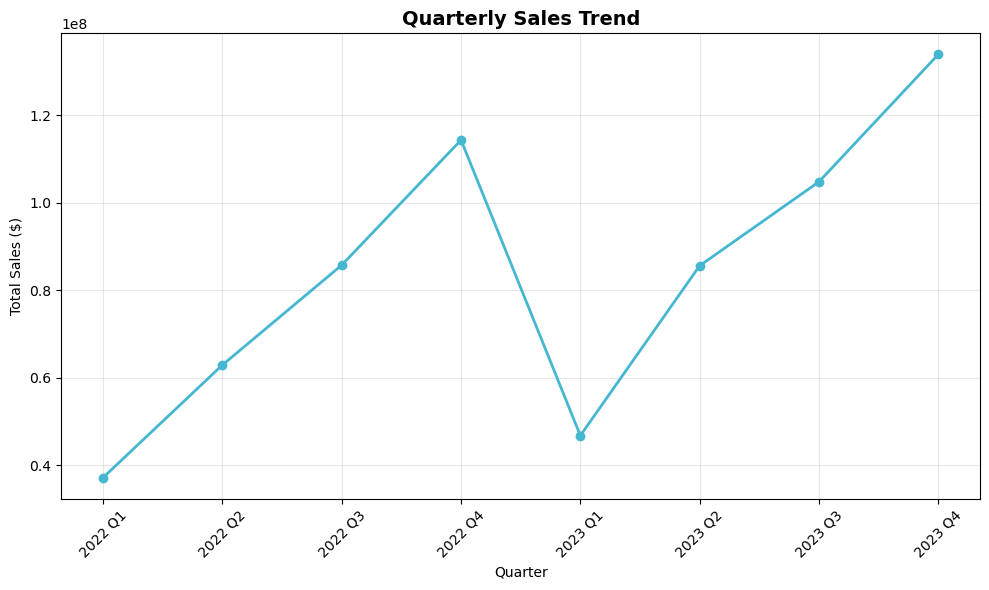

In [26]:
# Plot the line chart
plt.figure(figsize=(10, 6))
plt.plot(
    quarter_sales['Period'],
    quarter_sales['Sale_Price'],
    marker='o',
    color='#45B7D1',
    linewidth=2,
)

plt.title('Quarterly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
#2-TOTAL SALES BY REGION (in million)------------
# Merge the fact table with the region dimension to bring region names
df_sales_fact = df_sales_fact.merge(df_dealer_dim[['Dealer_Index', 'Region_Index']], on='Dealer_Index', how='left')
df_sales_fact = df_sales_fact.merge(df_region_dim[['Region_Index', 'Dealer_Region']], on='Region_Index', how='left')


In [28]:
# Group total sales by region
region_sales = df_sales_fact.groupby('Region_Index')['Sale_Price'].sum().reset_index()


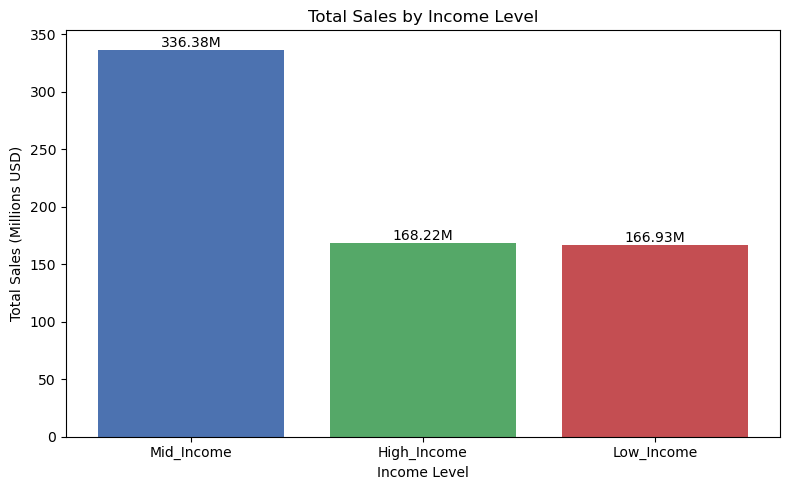

In [29]:
#TOTAL SALES BY INCOME LEVEL--------------
# Group total sales by Income Level
income_sales = df_fact.groupby('Income_Level')['Price ($)'].sum().reset_index()

# Sort income levels for clarity
income_sales = income_sales.sort_values(by='Price ($)', ascending=False)

# Divide by 1M for readability
income_sales['Price ($)'] = income_sales['Price ($)'] / 1_000_000

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(income_sales['Income_Level'], income_sales['Price ($)'], color=['#4C72B0', '#55A868', '#C44E52'])
# Add labels on bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height():.2f}M", ha='center', va='bottom', fontsize=10)

plt.title('Total Sales by Income Level')
plt.xlabel('Income Level')
plt.ylabel('Total Sales (Millions USD)')
plt.tight_layout()
plt.show()


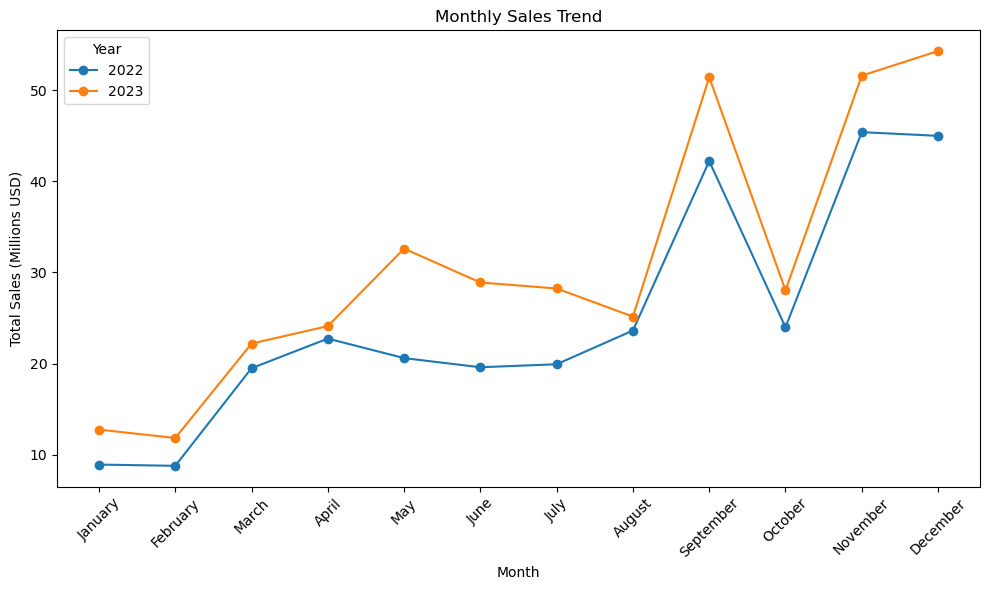

In [30]:
#3-SALES TREND BY MONTH-----------------------
# Convert to datetime (in case it's not)
df_fact['Date'] = pd.to_datetime(df_fact['Date'])

# Extract Year and Month from Date
df_fact['Year'] = df_fact['Date'].dt.year
df_fact['Month Name'] = df_fact['Date'].dt.strftime('%B')

# Group by Year and Month to calculate total sales
monthly_sales = df_fact.groupby(['Year', 'Month Name'])['Price ($)'].sum().reset_index()

# Ensure months appear in correct order
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_sales['Month Name'] = pd.Categorical(monthly_sales['Month Name'], categories=month_order, ordered=True)
monthly_sales = monthly_sales.sort_values(['Year', 'Month Name'])
# Convert to millions for clarity
monthly_sales['Price ($)'] = monthly_sales['Price ($)'] / 1_000_000

# Plot monthly trend
plt.figure(figsize=(10,6))
for year in monthly_sales['Year'].unique():
    subset = monthly_sales[monthly_sales['Year'] == year]
    plt.plot(subset['Month Name'], subset['Price ($)'], marker='o', label=f'{year}')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales (Millions USD)')
plt.legend(title='Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

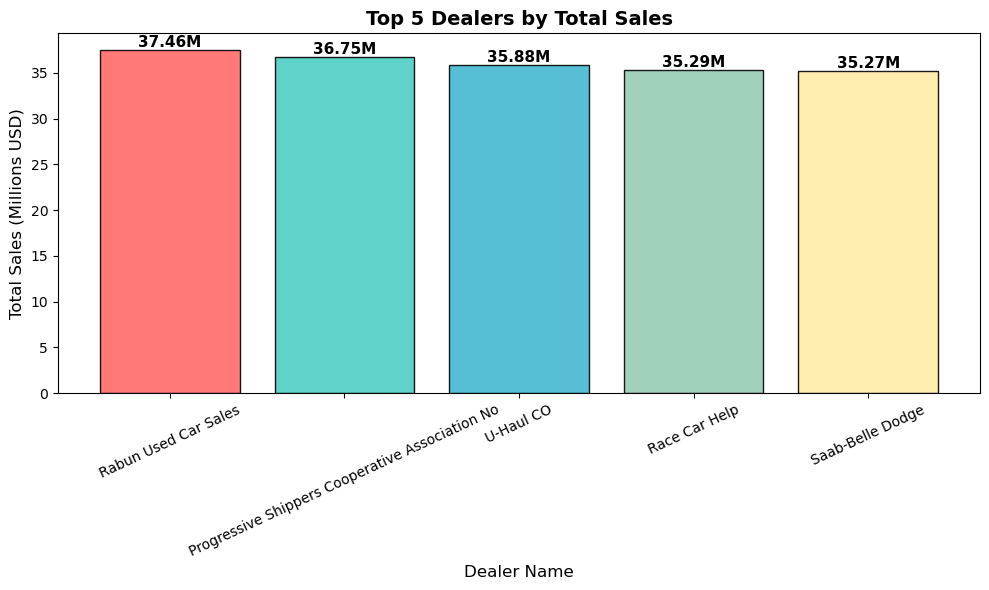

In [31]:
#4-TOP 5 DEALERS BY TOTAL SALES# Group by dealer and sum total sales
top_dealers = (
    df_fact.groupby('Dealer_Name')['Price ($)']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

# Convert sales to millions
top_dealers['Price_M'] = top_dealers['Price ($)'] / 1_000_000

# Color list (5 different colors)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

plt.figure(figsize=(10,6))
bars = plt.bar(
    top_dealers['Dealer_Name'],
    top_dealers['Price_M'],
    color=colors,
    edgecolor='black',
    alpha=0.9
)

# Add labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}M",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Titles and axis labels
plt.title('Top 5 Dealers by Total Sales', fontsize=14, fontweight='bold')
plt.xlabel('Dealer Name', fontsize=12)
plt.ylabel('Total Sales (Millions USD)', fontsize=12)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


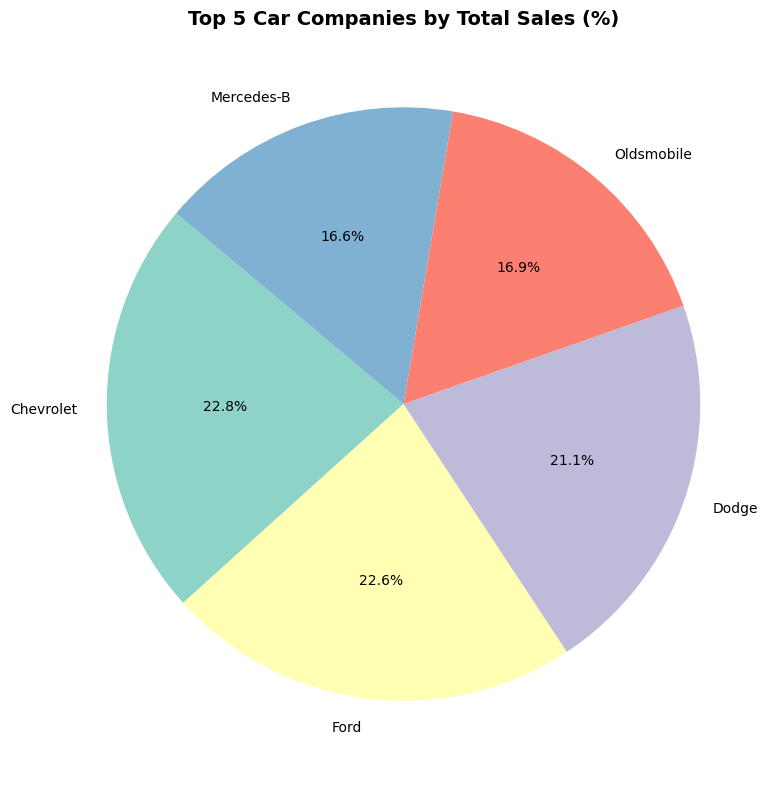

In [32]:
#5-TOP 5 car company BY TOTAL SALES(percentage)
# Group total sales by company
company_sales = df_fact.groupby('Company')['Price ($)'].sum().reset_index()

# Sort and keep only the top 5 companies
top5_companies = company_sales.sort_values(by='Price ($)', ascending=False).head(5)

# Calculate percentage
top5_companies['Percentage'] = (top5_companies['Price ($)'] / top5_companies['Price ($)'].sum()) * 100

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(top5_companies['Price ($)'],
        labels=top5_companies['Company'],
        autopct='%1.1f%%',
        startangle=140,
        colors=plt.cm.Set3.colors)

plt.title('Top 5 Car Companies by Total Sales (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

